## **LOAD DATA SHOPEE**

In [1]:
import pandas as pd

In [2]:
shopee = pd.read_csv('/content/data_shopee_kotor.csv')
shopee

,link_produk,judul_produk,harga,potongan_harga,flex-none src,rating,terjual,jenis,inline src,kota
0,https://shopee.co.id/devilmimi-realme-C71-8GB-...,devilmimi realme C71 8GB+16GB / 128GB Handphon...,2.139.000,-55%,https://deo.shopeemobile.com/shopee/modules-fe...,4.9,568 Terjual,4 jam,https://deo.shopeemobile.com/shopee/modules-fe...,Surabaya
1,https://shopee.co.id/devilmimi-realme-series-C...,devilmimi realme series C71 4GB+8GB / 128 GB b...,1.792.000,-55%,https://deo.shopeemobile.com/shopee/modules-fe...,5.0,225 Terjual,4 jam,https://deo.shopeemobile.com/shopee/modules-fe...,Surabaya
2,https://shopee.co.id/-BARU-OPPO-A6t-Online-Exc...,[BARU] OPPO A6t Online Exclusive 4+64/128GB & ...,1.999.000,NaN,https://deo.shopeemobile.com/shopee/modules-fe...,4.9,3RB+ Terjual,2-4 Hari,https://deo.shopeemobile.com/shopee/modules-fe...,Tangerang
3,https://shopee.co.id/Samsung-Galaxy-A07-4-64GB...,Samsung Galaxy A07 4/64GB - Black,1.599.000,-6%,https://deo.shopeemobile.com/shopee/modules-fe...,4.9,10RB+ Terjual,5 jam,https://deo.shopeemobile.com/shopee/modules-fe...,Surabaya
4,https://shopee.co.id/itel-City200-NFC-RAM-128-...,itel City200 NFC RAM 128+8GB(4+4GB) - Big Batt...,1.548.000,-38%,https://deo.shopeemobile.com/shopee/modules-fe...,4.9,1RB+ Terjual,Besok,https://deo.shopeemobile.com/shopee/modules-fe...,Jakarta Barat
...,...,...,...,...,...,...,...,...,...,...
1189,https://shopee.co.id/Xiaomi-Redmi-Note-14-5G-1...,Xiaomi Redmi Note 14 5G 12+512GB Bisa Paylater...,3.329.000,NaN,https://deo.shopeemobile.com/shopee/modules-fe...,5.0,67 Terjual,5 jam,https://deo.shopeemobile.com/shopee/modules-fe...,Surabaya
1190,https://shopee.co.id/Samsung-Galaxy-A25-5G-8-2...,Samsung Galaxy A25 5G 8/256 Gb Handphone Terba...,3.799.000,NaN,https://deo.shopeemobile.com/shopee/modules-fe...,5.0,72 Terjual,< 2 Hari,https://deo.shopeemobile.com/shopee/modules-fe...,Surabaya
1191,https://shopee.co.id/Vivo-Y28-Ram-6-128GB-Ram-...,Vivo Y28 Ram 6/128GB | Ram 8/128GB | Ram 8/256...,1.680.999,-44%,https://deo.shopeemobile.com/shopee/modules-fe...,4.9,31 Terjual,4 jam,https://deo.shopeemobile.com/shopee/modules-fe...,Surabaya
1192,https://shopee.co.id/POCO-X7-Pro-5G-12-512-GB-...,POCO X7 Pro 5G 12/512 GB Original New Garansi ...,5.249.000,NaN,https://deo.shopeemobile.com/shopee/modules-fe...,5.0,64 Terjual,4 jam,https://deo.shopeemobile.com/shopee/modules-fe...,Kab. Sidoarjo


## **PREPROCESSING**

In [3]:
shopee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   link_produk     1194 non-null   object 
 1   judul_produk    1194 non-null   object 
 2   harga           1194 non-null   object 
 3   potongan_harga  542 non-null    object 
 4   flex-none src   1167 non-null   object 
 5   rating          1167 non-null   float64
 6   terjual         1180 non-null   object 
 7   jenis           1187 non-null   object 
 8   inline src      1174 non-null   object 
 9   kota            1174 non-null   object 
dtypes: float64(1), object(9)
memory usage: 93.4+ KB


In [4]:
# Pengecekan missing value
shopee.isnull().sum()

,0
link_produk,0
judul_produk,0
harga,0
potongan_harga,652
flex-none src,27
rating,27
terjual,14
jenis,7
inline src,20
kota,20


In [5]:
# Pengecekan data duplikat
shopee.duplicated().sum()

np.int64(0)

#### Seleksi Kolom (Drop yang Tidak Digunakan)

In [6]:
# Kolom yang digunakan
kolom_shopee = ['judul_produk', 'harga', 'terjual', 'kota']
shopee = shopee[kolom_shopee].copy()

print("Kolom setelah diseleksi:", shopee.columns.tolist())
print("Shape:", shopee.shape)

Kolom setelah diseleksi: ['judul_produk', 'harga', 'terjual', 'kota']
Shape: (1194, 4)


In [7]:
# Rename kolom
shopee = shopee.rename(columns = {
    'judul_produk': 'Produk',
    'harga': 'Harga_Produk',
    'terjual': 'Produk_Terjual',
    'kota': 'Lokasi_Toko'})

print("Kolom setelah rename:", shopee.columns.tolist())

Kolom setelah rename: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko']


#### Tambahkan Kolom Identitas Platform

In [8]:
shopee['E-Commerce'] = 'Shopee'
print(shopee['E-Commerce'].value_counts())

E-Commerce
Shopee    1194
Name: count, dtype: int64


In [9]:
shopee.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce
0,devilmimi realme C71 8GB+16GB / 128GB Handphon...,2.139.000,568 Terjual,Surabaya,Shopee
1,devilmimi realme series C71 4GB+8GB / 128 GB b...,1.792.000,225 Terjual,Surabaya,Shopee
2,[BARU] OPPO A6t Online Exclusive 4+64/128GB & ...,1.999.000,3RB+ Terjual,Tangerang,Shopee
3,Samsung Galaxy A07 4/64GB - Black,1.599.000,10RB+ Terjual,Surabaya,Shopee
4,itel City200 NFC RAM 128+8GB(4+4GB) - Big Batt...,1.548.000,1RB+ Terjual,Jakarta Barat,Shopee


#### Filter Produk HP (Drop Selain Produk HP)

In [10]:
# Membuat kata kunci penanda produk non-hp
non_hp_keywords = ['headset', 'earphone', 'earbuds', 'tws', 'charger', 'casing', 'softcase',
                   'hardcase', 'tempered', 'glass', 'kabel', 'cable', 'powerbank', 'power bank',
                   'lcd', 'spare', 'baterai', 'battery', 'tripod', 'holder', 'stand', 'stylus',
                   'adapter', 'converter', 'memory', 'micro sd', 'microsd', 'tablet', 'smartwatch',
                   'watch']

def is_hp(judul):
    judul_lower = str(judul).lower()
    for kw in non_hp_keywords:
        if kw in judul_lower:
            return False
    return True

sebelum = shopee.shape[0]
shopee = shopee[shopee['Produk'].apply(is_hp)].reset_index(drop = True)
sesudah = shopee.shape[0]

print(f"Baris sebelum filter: {sebelum}")
print(f"Baris setelah filter: {sesudah}")
print(f"Produk non-HP yang dibuang: {sebelum - sesudah}")

Baris sebelum filter: 1194
Baris setelah filter: 1015
Produk non-HP yang dibuang: 179


#### Cleaning Kolom Harga Produk

In [11]:
shopee['Harga_Produk'] = (
    shopee['Harga_Produk']
    .astype(str)
    .str.replace('.', '', regex=False)   # hapus titik pemisah ribuan
    .str.replace(',', '', regex=False)   # hapus koma
    .str.replace('Rp', '', regex=False)  # hapus prefix Rp a
    .str.strip()                         # hapus spasi di awal/akhir
)

shopee['Harga_Produk'] = pd.to_numeric(shopee['Harga_Produk'], errors = 'coerce')

In [12]:
# Tipe data
print("Tipe data harga:", shopee['Harga_Produk'].dtype)

Tipe data harga: int64


In [13]:
# Pengecekan missing value kolom harga produk
shopee['Harga_Produk'].isnull().sum()

np.int64(0)

In [14]:
# Statistika deskriptif
shopee['Harga_Produk'].describe()

,Harga_Produk
count,1.015000e+03
mean,3.600422e+06
std,3.442864e+06
min,5.613000e+03
25%,1.549000e+06
50%,2.479000e+06
75%,4.799000e+06
max,2.699900e+07


#### Cleaning Kolom Produk Terjual

In [15]:
import numpy as np
import re

In [16]:
def parse_terjual(val):
    val = str(val).lower().strip()
    val = val.replace('terjual', '').replace('sold', '').strip()

    # Handle format "3rb+" atau "3RB+"
    match_rb = re.search(r'([\d.,]+)\s*rb', val)
    if match_rb:
        angka = match_rb.group(1).replace(',', '.').replace('.', '')
        return float(angka) * 1000

    # Handle format "3k+" atau "3K+"
    match_k = re.search(r'([\d.,]+)\s*k', val)
    if match_k:
        angka = match_k.group(1).replace(',', '').replace('.', '')
        return float(angka) * 1000

    # Handle angka biasa
    val_clean = re.sub(r'[^\d]', '', val)
    if val_clean:
        return float(val_clean)

    return np.nan

shopee['Produk_Terjual'] = shopee['Produk_Terjual'].apply(parse_terjual)
shopee['Produk_Terjual'] = pd.to_numeric(shopee['Produk_Terjual'], errors = 'coerce')

In [17]:
# Tipe data
print("Tipe data terjual:", shopee['Produk_Terjual'].dtype)

Tipe data terjual: float64


In [18]:
# Pengecekan missing value
shopee['Produk_Terjual'].isnull().sum()

np.int64(14)

In [19]:
# Statistika deskriptif
shopee['Produk_Terjual'].describe().round(3)

,Produk_Terjual
count,1001.000
mean,901.828
std,1814.969
min,1.000
25%,39.000
50%,189.000
75%,833.000
max,10000.000


#### Cleaning Kolom Kota

In [20]:
shopee['Lokasi_Toko'].unique()

array(['Surabaya', 'Jakarta Utara', 'Jakarta Barat', 'Bogor',
       'Kab. Kota Waringin Timur', 'Jakarta Pusat', 'Malang',
       'Jakarta Selatan', 'Semarang', 'Kab. Tangerang', 'Kab. Sidoarjo',
       'Bekasi', 'Samarinda', 'Kab. Sleman', nan, 'Tangerang',
       'Banjarbaru', 'Balikpapan', 'Banjarmasin', 'Bandung',
       'Kab. Ponorogo', 'Kab. Mojokerto', 'Makassar', 'Denpasar', 'Depok',
       'Palangka Raya', 'Kab. Bogor', 'Kab. Jember', 'Kab. Badung',
       'Kab. Buleleng', 'Tangerang Selatan', 'Kab. Majalengka',
       'Jakarta Timur', 'Tasikmalaya', 'Medan', 'Kab. Malang',
       'Surakarta (Solo)', 'Pekanbaru', 'Mojokerto', 'Kediri', 'Serang',
       'Palembang', 'Kab. Cirebon', 'Batu', 'Kab. Gianyar',
       'Kab. Bojonegoro', 'Kab. Sukoharjo', 'Kab. Banyumas',
       'Kab. Gresik', 'Kab. Kulon Progo', 'Madiun', 'Kab. Kuningan',
       'Pasuruan', 'Kab. Banyuwangi', 'Kab. Klungkung', 'Kab. Nganjuk',
       'Kab. Jombang', 'Manado', 'Mataram', 'Kab. Karawang', 'Kab. Tuban',

In [21]:
def normalize_location(location):
    if pd.isna(location):
        return np.nan

    original_text = str(location).lower().strip()
    processed_text = original_text
    # Remove content in parentheses, e.g., "Surakarta (Solo)" -> "Surakarta"
    processed_text = re.sub(r'\s*\(.*\)', '', processed_text).strip()

    city_mapping = {
        'surabaya': 'surabaya (kota)',
        'jakarta utara': 'jakarta utara (kota)',
        'jakarta barat': 'jakarta barat (kota)',
        'bogor': 'bogor (kota)',
        'jakarta pusat': 'jakarta pusat (kota)',
        'malang': 'malang (kota)',
        'jakarta selatan': 'jakarta selatan (kota)',
        'semarang': 'semarang (kota)',
        'bekasi': 'bekasi (kota)',
        'samarinda': 'samarinda (kota)',
        'tangerang': 'tangerang (kota)',
        'banjarbaru': 'banjarbaru (kota)',
        'balikpapan': 'balikpapan (kota)',
        'banjarmasin': 'banjarmasin (kota)',
        'bandung': 'bandung (kota)',
        'makassar': 'makassar (kota)',
        'denpasar': 'denpasar (kota)',
        'depok': 'depok (kota)',
        'palangka raya': 'palangka raya (kota)',
        'tangerang selatan': 'tangerang selatan (kota)',
        'jakarta timur': 'jakarta timur (kota)',
        'tasikmalaya': 'tasikmalaya (kota)',
        'medan': 'medan (kota)',
        'surakarta': 'surakarta (kota)',
        'pekanbaru': 'pekanbaru (kota)',
        'mojokerto': 'mojokerto (kota)',
        'kediri': 'kediri (kota)',
        'serang': 'serang (kota)',
        'palembang': 'palembang (kota)',
        'batu': 'batu (kota)',
        'madiun': 'madiun (kota)',
        'pasuruan': 'pasuruan (kota)',
        'manado': 'manado (kota)',
        'mataram': 'mataram (kota)'
    }

    kabupaten_names = {
        'sidoarjo', 'sleman', 'ponorogo', 'mojokerto', 'bogor', 'jember', 'badung',
        'buleleng', 'majalengka', 'malang', 'cirebon', 'gianyar', 'bojonegoro',
        'sukoharjo', 'banyumas', 'gresik', 'kulon progo', 'kuningan', 'banyuwangi',
        'klungkung', 'nganjuk', 'jombang', 'karawang', 'tuban', 'garut', 'serang',
        'bekasi', 'kotawaringin timur', 'tangerang'
    }

    if processed_text.startswith('kab. '):
        base_name = processed_text[4:].strip()
        # Penanganan Khusus "Kab. Kota Waringin Timur"
        if base_name == 'kota waringin timur':
            base_name = 'kotawaringin timur'
        return f"{base_name} (kabupaten)"
    elif processed_text.startswith('kota '):
        base_name = processed_text[5:].strip()
        return f"{base_name} (kota)"

    if processed_text in city_mapping:
        return city_mapping[processed_text]
    elif processed_text in kabupaten_names:
        return f"{processed_text} (kabupaten)"
    else:
        return processed_text

In [22]:
shopee['Lokasi_Toko'] = shopee['Lokasi_Toko'].apply(normalize_location)

# Jumlah lokasi setelah di normalisasi
shopee['Lokasi_Toko'].value_counts()

,count
Lokasi_Toko,
surabaya (kota),277
jakarta utara (kota),154
jakarta barat (kota),86
tangerang (kota),48
jakarta pusat (kota),47
...,...
manado (kota),1
karawang (kabupaten),1
garut (kabupaten),1


#### Penanganan Missing Value

In [23]:
print("Missing values sebelum ditangani:\n")
shopee.isnull().sum()

Missing values sebelum ditangani:



,0
Produk,0
Harga_Produk,0
Produk_Terjual,14
Lokasi_Toko,14
E-Commerce,0


In [24]:
# Kolom Terjual (imputasi dengan 0 (tidak diketahui = anggap belum terjual))
shopee['Produk_Terjual'] = shopee['Produk_Terjual'].fillna(0)
print(f"Produk Terjual diimputasi dengan 0: {shopee['Produk_Terjual'].isnull().sum()}")

# Kolom Lokasi (imputasi dengan modus (kota terbanyak))
shopee['Lokasi_Toko'] = shopee['Lokasi_Toko'].fillna('Tidak Diketahui')
print(f"Lokasi null diisi 'Tidak Diketahui': {(shopee['Lokasi_Toko'] == 'Tidak Diketahui').sum()} baris")

Produk Terjual diimputasi dengan 0: 0
Lokasi null diisi 'Tidak Diketahui': 14 baris


In [25]:
print("Missing values setelah imputasi:\n")
shopee.isnull().sum()

Missing values setelah imputasi:



,0
Produk,0
Harga_Produk,0
Produk_Terjual,0
Lokasi_Toko,0
E-Commerce,0


## **VISUALISASI DAN PENYIMPANAN DATASET**

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

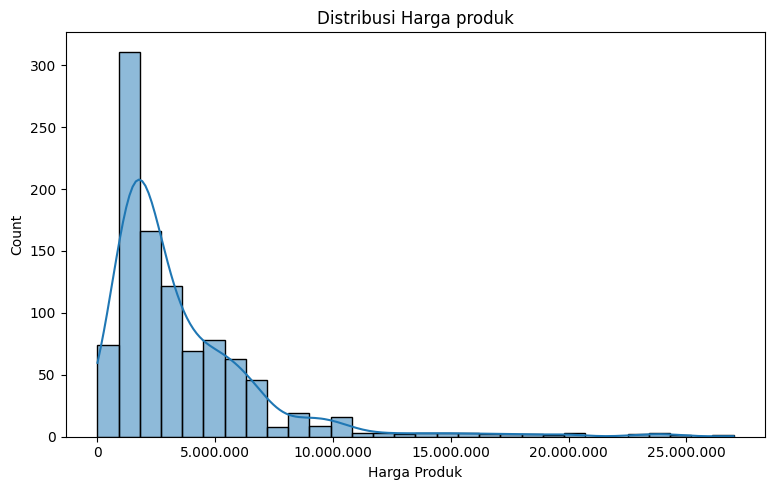

In [27]:
plt.figure(figsize = (15, 5))

# Plot 1: Distribusi dari Harga Produk
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(shopee['Harga_Produk'], bins = 30, kde = True)
plt.title('Distribusi Harga produk')
plt.xlabel('Harga Produk')
plt.ylabel('Count')

# Format x-axis labels (agar menampilkan angka harga lengkap dengan pemisah titik)
def currency_formatter(x, pos):
    return f'{int(x):,}'.replace(',', '.')

formatter = mticker.FuncFormatter(currency_formatter)
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

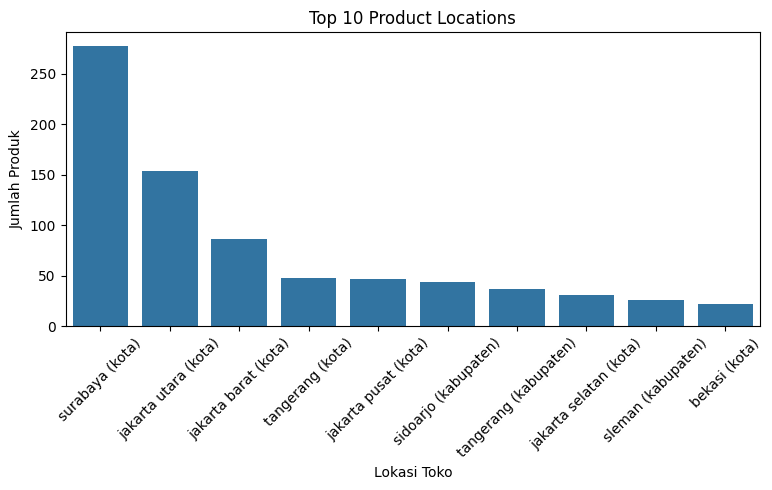

In [28]:
plt.figure(figsize = (15, 5))

# Plot 2: Top 10 dari Lokasi Toko
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
top_locations = shopee['Lokasi_Toko'].value_counts().head(10)
sns.barplot(x = top_locations.index, y = top_locations.values)
plt.title('Top 10 Product Locations')
plt.xlabel('Lokasi Toko')
plt.ylabel('Jumlah Produk')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

#### Penyimpanan Data

In [29]:
# Jumlah akhir data shopee
print(f"Jumlah Data Setelah Preprocessing: {shopee.shape[0]} baris, {shopee.shape[1]} kolom")

Jumlah Data Setelah Preprocessing: 1015 baris, 5 kolom


In [30]:
# Nama kolom
print(f"Kolom: {shopee.columns.tolist()}")

Kolom: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko', 'E-Commerce']


In [31]:
# Pengecekan data
shopee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Produk          1015 non-null   object 
 1   Harga_Produk    1015 non-null   int64  
 2   Produk_Terjual  1015 non-null   float64
 3   Lokasi_Toko     1015 non-null   object 
 4   E-Commerce      1015 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 39.8+ KB


In [32]:
# Statistika deskriptif
shopee.describe().round(3)

,Harga_Produk,Produk_Terjual
count,1.015000e+03,1015.000
mean,3.600422e+06,889.389
std,3.442864e+06,1805.466
min,5.613000e+03,0.000
25%,1.549000e+06,36.000
50%,2.479000e+06,173.000
75%,4.799000e+06,808.000
max,2.699900e+07,10000.000


In [33]:
# Data final
shopee.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce
0,devilmimi realme C71 8GB+16GB / 128GB Handphon...,2139000,568.0,surabaya (kota),Shopee
1,Samsung Galaxy A07 4/64GB - Black,1599000,10000.0,surabaya (kota),Shopee
2,Samsung Galaxy A16 8/128GB - Black,2759000,10000.0,jakarta utara (kota),Shopee
3,HP IPHONE 14 128GB - Garansi Resmi Indonesia,9165000,13.0,surabaya (kota),Shopee
4,Infinix Hot 60i 6/128GB - Up to 12GB Extended ...,1799000,10000.0,jakarta utara (kota),Shopee


In [34]:
# Simpan hasil
shopee.to_csv('data_shopee_clean.csv', index = False)
print("File _data_shopee_clean.csv berhasil disimpan!")

File _data_shopee_clean.csv berhasil disimpan!
